In [ ]:
import polars as pl
import numpy as np
from pathlib import Path

from dataclasses import dataclass

In [26]:
@dataclass
class ModelData:
    data = {"train": None, "test": None}

    def load_data(self, split, files):
        data_frames = []
        for file in files:
            df = pl.read_parquet(Path(f"data/prepared/{file}.parquet"))
            df = df.drop(["raw_t_ms", "t_ms"])
            data_frames.append(df)

        self.data[split] = pl.concat(data_frames) if data_frames else pl.DataFrame()

In [199]:
split = {"train": ["g_v01", "g_v01_1", "g_ws0"], "test": ["g_v02", "g_ws1"]}

model_data = ModelData()
for split_name, files in split.items():
    model_data.load_data(split_name, files)

print(model_data.data)

{'train': shape: (24_347, 8)
┌───────┬───────┬───────┬────────┬────────┬────────┬──────────┬───────┐
│ acc_x ┆ acc_y ┆ acc_z ┆ gyro_x ┆ gyro_y ┆ gyro_z ┆ acc_norm ┆ drink │
│ ---   ┆ ---   ┆ ---   ┆ ---    ┆ ---    ┆ ---    ┆ ---      ┆ ---   │
│ f64   ┆ f64   ┆ f64   ┆ f64    ┆ f64    ┆ f64    ┆ f64      ┆ i64   │
╞═══════╪═══════╪═══════╪════════╪════════╪════════╪══════════╪═══════╡
│ 1.02  ┆ 0.95  ┆ 9.43  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 9.53246  ┆ 0     │
│ 1.02  ┆ 0.94  ┆ 9.46  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 9.561151 ┆ 0     │
│ 1.04  ┆ 0.93  ┆ 9.41  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 9.512865 ┆ 0     │
│ 1.01  ┆ 0.96  ┆ 9.43  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 9.532397 ┆ 0     │
│ 1.02  ┆ 0.94  ┆ 9.44  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 9.541363 ┆ 0     │
│ …     ┆ …     ┆ …     ┆ …      ┆ …      ┆ …      ┆ …        ┆ …     │
│ 1.15  ┆ 0.95  ┆ 9.44  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 9.557123 ┆ 0     │
│ 1.16  ┆ 0.96  ┆ 9.44  ┆ -0.08  ┆ 0.03   ┆ -0.01  ┆ 9.559331 ┆ 0     │
│ 1.15  ┆ 0.95  ┆ 9.43  ┆ -0.08  ┆ 

Text(0.5, 1.0, 'Correlation Matrix')

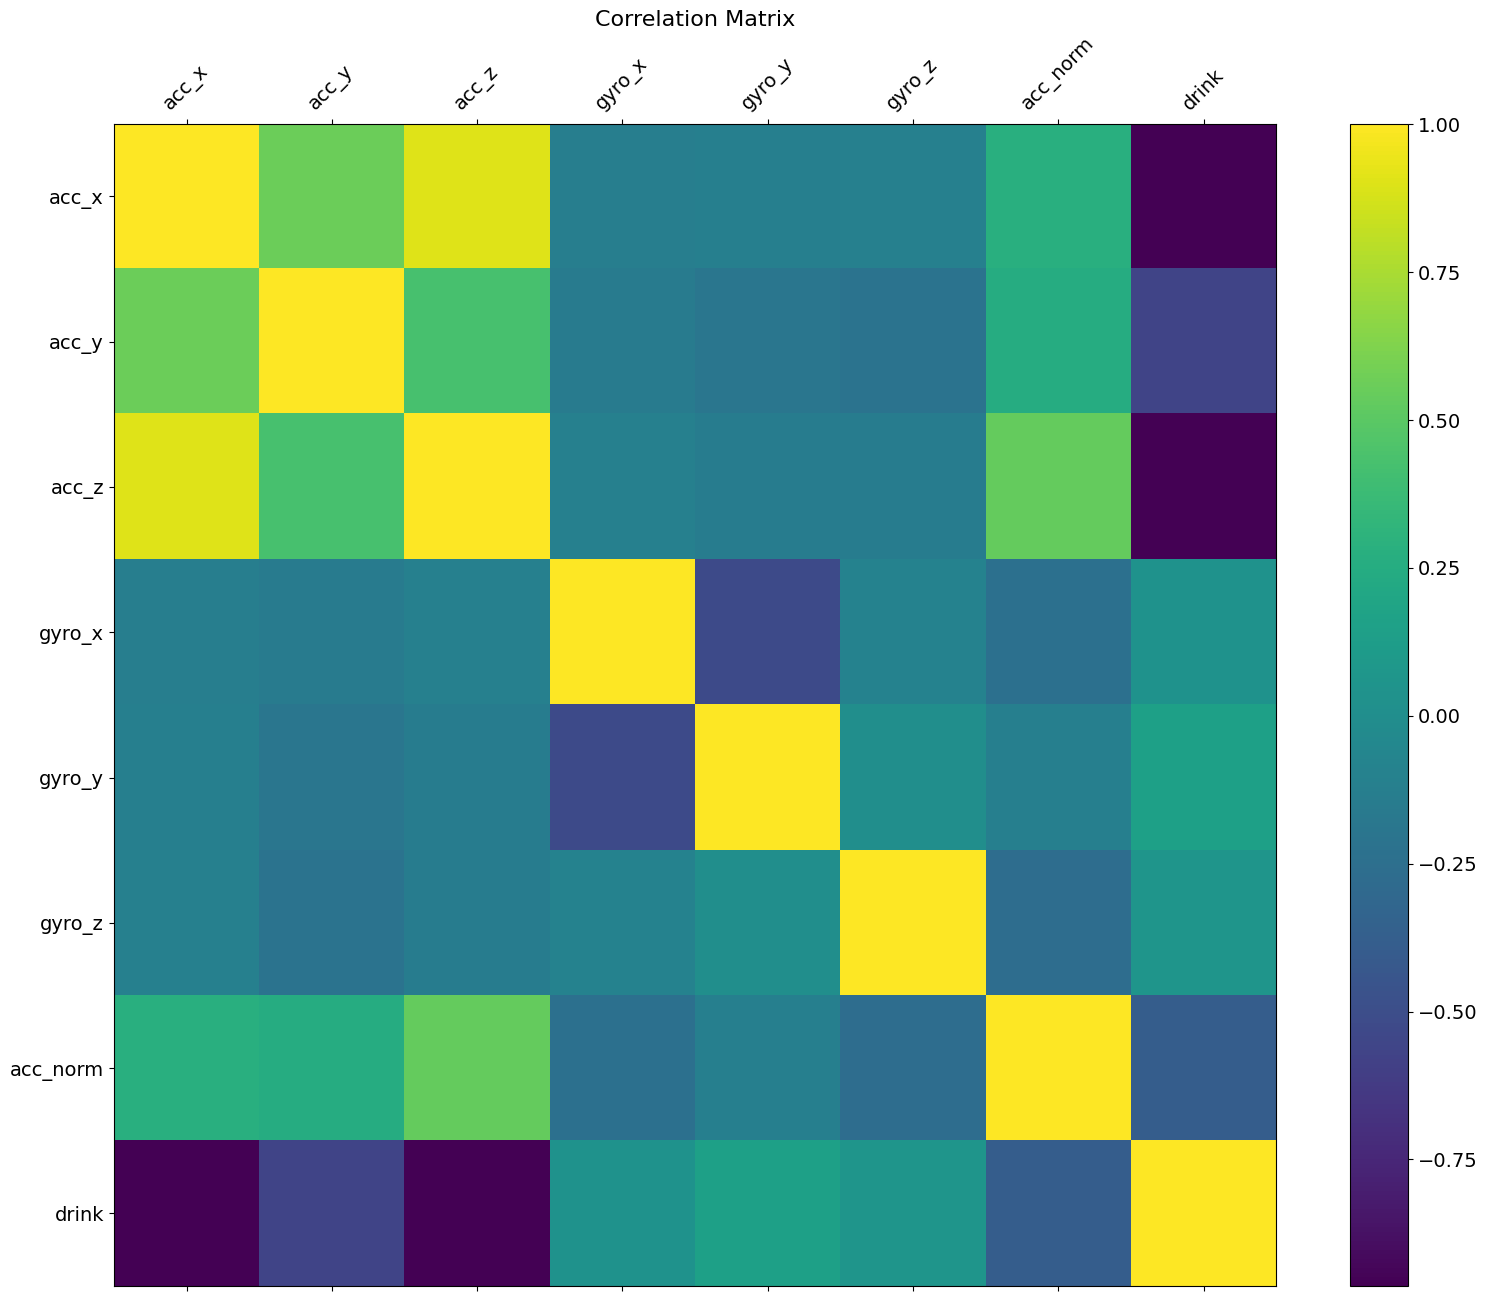

In [194]:
import matplotlib.pyplot as plt

df = model_data.data["train"].corr().to_pandas()
f = plt.figure(figsize=(19, 15))
plt.matshow(df.corr(), fignum=f.number)
plt.xticks(
    range(df.select_dtypes(["number"]).shape[1]),
    df.select_dtypes(["number"]).columns,
    fontsize=14,
    rotation=45,
)
plt.yticks(
    range(df.select_dtypes(["number"]).shape[1]),
    df.select_dtypes(["number"]).columns,
    fontsize=14,
)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title("Correlation Matrix", fontsize=16)

## Models

In [170]:
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, SGDRegressor, RidgeClassifier

In [219]:
def mae(y_true, y_pred):
    return np.abs(y_true - y_pred).mean()


def rmse(y_true, y_pred):
    return np.sqrt(np.pow(y_true - y_pred, 2).mean())


def accuracy(y_true, y_pred):
    return (y_true == y_pred).sum() / len(y_pred)


class ModelClass:
    def __init__(self, data):
        self.model = None
        self.models = {
            "linear": LinearRegression(),
            "logistic": LogisticRegression(random_state=16),
            "ridge": Ridge(),
            "ridge_cv": RidgeCV(),
            "SGDRegressor": SGDRegressor(),
            "ridge_classifier": RidgeClassifier(),
        }
        self.train_data = data["train"]
        self.test_data = data["test"]#.filter(pl.col("drink") == 1)
        self.filter_columns = None

    def training(self, model_type: str = "linear"):
        y = self.train_data[["drink"]].to_numpy()

        if self.filter_columns is not None:
            X = self.train_data[self.filter_columns].to_numpy()
        else:
            X = self.train_data.drop("drink").to_numpy()

        self.model = self.models[model_type]
        self.model.fit(X, y.ravel())

        # print(f"Model trained with score: {self.model.score(X, y):.2f}")
        # print(f"slope: {self.model.coef_}")
        return self.model.score(X, y)

    def predict(self, columns: list = None):
        if self.filter_columns is not None:
            X = self.test_data[self.filter_columns].to_numpy()
        else:
            X = self.test_data.drop("drink").to_numpy()

        return self.model.predict(X).flatten()

    def evaluate(self, predicted, treshold: float = 0.5, plot: bool = False):
        predicted = np.where(predicted < treshold, predicted, 1)
        predicted = np.where(predicted > treshold, predicted, 0)

        test_y = self.test_data["drink"].to_numpy()

        if plot:
            f = plt.figure(figsize=(16, 9))
            plt.plot(predicted)
            plt.plot(test_y)
            plt.show()

        results = {
            "mae": mae(test_y, predicted),
            "accuracy": accuracy(test_y, predicted),
            "rmse": rmse(test_y, predicted),
        }

        return results

In [220]:
model_class = ModelClass(model_data.data)

test_clomuns = {
    "all": None,
    "all_acc_gyro": ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"],
    "best_corr": ["acc_x", "acc_z", "gyro_y"],
    "simple": ["acc_x", "gyro_y"],
    "all_gyros_acc_x": ["acc_x", "gyro_y", "gyro_z", "gyro_x"],
    "all_acc_and_gyro_y": ["acc_x", "acc_y", "acc_z", "gyro_y"],
}

final_results = []
for m in model_class.models.keys():
    for label, cols in test_clomuns.items():
        model_class.filter_columns = cols
        score = model_class.training(model_type=m)
        predicted = model_class.predict()
        result = model_class.evaluate(predicted)

        result["score"] = score
        result["label"] = label
        result["model"] = m
        final_results.append(result)
        #break
        # print(f"Results for {label}: {result}")

pl.DataFrame(final_results).sort(["accuracy", "rmse"], descending=[True, False])

mae,accuracy,rmse,score,label,model
f64,f64,f64,f64,str,str
0.010737,0.989263,0.103619,0.989937,"""all_gyros_acc_x""","""logistic"""
0.010884,0.989116,0.104326,0.99006,"""simple""","""logistic"""
0.011252,0.988748,0.106074,0.989855,"""all_gyros_acc_x""","""ridge_classifier"""
0.011252,0.988748,0.106074,0.553756,"""all_gyros_acc_x""","""linear"""
0.011252,0.988748,0.106074,0.553756,"""all_gyros_acc_x""","""ridge_cv"""
…,…,…,…,…,…
0.016179,0.983821,0.127196,0.992607,"""all""","""ridge_classifier"""
0.016179,0.983821,0.127196,0.729568,"""all""","""linear"""
0.016179,0.983821,0.127196,0.729568,"""all""","""ridge"""


Generate analyse consider only drinks in test case,, to evaluate perfomance just in this cases